In [11]:
import os
import sys
from pathlib import Path
from src.prometheus_io import prom_query_range, prom_query_instant, test_connection
import src.prometheus_io as pio
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt

In [16]:
PROMETHEUS_URL = "http://178.104.69.73:9090"
TIME_WINDOW_HOURS = 1
END = datetime.now(timezone.utc)
START = END - timedelta(hours=TIME_WINDOW_HOURS)
STEP = '5s'
JOB = "chat-monolith"

In [17]:
connection_status = test_connection(PROMETHEUS_URL)
print('Connected: {}'.format(connection_status))

Connected: True


In [ ]:
# Load process cpu usage
proc_cpu = prom_query_range(
    f'process_cpu_usage{{job="{JOB}"}}',
    START,
    END,
    STEP,
    base_url=PROMETHEUS_URL,
)



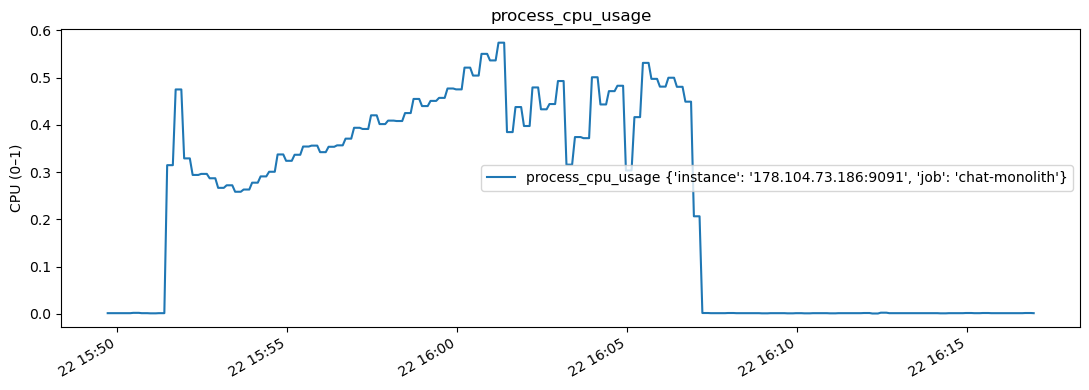

In [18]:
fig, ax = plt.subplots(figsize=(11, 4))
if not proc_cpu.empty:
    proc_cpu.plot(ax=ax, legend=True)
ax.set_title("process_cpu_usage")
ax.set_ylabel("CPU (0–1)")
fig.tight_layout()
plt.show()